
[![Electronic Profile](https://img.shields.io/badge/Electronic%20Profile-engineer--e-181717?logo=github)](https://github.com/engineer-e/) 
[![Work Profile](https://img.shields.io/badge/Work%20Profile-engineer--work-181717?logo=github)](https://github.com/engineer-work/) 
[![Instagram](https://img.shields.io/badge/Instagram-gobalkrishnan.engineer-E4405F?logo=instagram&logoColor=white)](https://www.instagram.com/gobalkrishnan.engineer/)

# 6. Surface Normals and Multiple Objects 


## 6.2 Simplifying the Ray-Sphere Intersection Code 

In [12]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

from util.ray import Ray
from util.vec3 import Vec3
from util.color import write_color
from util.vec3 import unit_vector
from util.vec3 import dot
from tqdm import tqdm
import math



# Old 

```python
def hit_sphere(center,  radius,  ray) :
     oc = center - ray.origin();
     a = dot(ray.direction(), ray.direction());
     b = -2.0 * dot(ray.direction(), oc);
     c = dot(oc, oc) - radius*radius;
     discriminant = b*b - 4*a*c;

     if (discriminant < 0) :
        return -1.0;
     else: 
        return (-b - math.sqrt(discriminant) ) / (2.0*a);
```


In [13]:
def hit_sphere(center,  radius,  ray) :
    oc = center - ray.origin();
    a = ray.direction().length_squared();
    h = dot(ray.direction(), oc);
    c = oc.length_squared() - radius*radius;
    discriminant = h*h - a*c;

    if (discriminant < 0) :
        return -1.0;
    else :
        return (h - math.sqrt(discriminant)) / a;
    


In [14]:

# -----------------------------
# Sky color function
# -----------------------------
def ray_color(ray):
    t = hit_sphere(Vec3(0,0,-1), 0.5, ray)
    if (t>0.0):
        N = unit_vector(ray.at(t) - Vec3(0,0,-1))
        return 0.5*Vec3(N.x+1,N.y+ 1,N.z+ 1);

    unit_direction = unit_vector(ray.direction())

    # scale y from [-1,1] to [0,1]
    a = 0.5 * (unit_direction.y + 1.0)

    white = Vec3(1.0, 1.0, 1.0)
    blue = Vec3(0.5, 0.7, 1.0)

    # lerp
    return white * (1.0 - a) + blue * a

In [15]:
# -----------------------------
# IMAGE / CAMERA SETUP
# -----------------------------

# Aspect ratio of the final image (width : height)
# Example: 16:9 widescreen
aspect_ratio = 16.0 / 9.0

# Total number of horizontal pixels
image_width = 1980

# Compute vertical pixels based on aspect ratio
image_height = int(image_width / aspect_ratio)


# -----------------------------
# CAMERA / VIEWPORT CONFIGURATION
# -----------------------------

# Distance between camera center and viewport
# This acts like "eye to retina" distance (focal length)
focal_length = 1

# Physical height of the viewport in world space
viewport_height = 2.0

# Physical width of viewport, scaled by aspect ratio
viewport_width = viewport_height * (image_width / image_height)

# Camera position (origin point)
# Think of this as the eye location
camera_center = Vec3(0, 0, 0)


# -----------------------------
# VIEWPORT AXIS VECTORS
# -----------------------------

# Horizontal vector of viewport
# Goes left → right
viewport_u = Vec3(viewport_width, 0, 0)

# Vertical vector of viewport
# Negative y means top → down
viewport_v = Vec3(0, -viewport_height, 0)


# -----------------------------
# PIXEL SIZE IN WORLD SPACE
# -----------------------------

# Width of one pixel in viewport space
pixel_delta_u = viewport_u / image_width

# Height of one pixel in viewport space
pixel_delta_v = viewport_v / image_height


# -----------------------------
# VIEWPORT POSITIONING
# -----------------------------

# Find the top-left corner of the viewport
#
# Steps:
# 1. Move forward along z-axis by focal length
# 2. Shift left by half viewport width
# 3. Shift up by half viewport height
viewport_upper_left = (
    camera_center
    - Vec3(0, 0, focal_length)
    - viewport_u / 2
    - viewport_v / 2
)


# -----------------------------
# FIRST PIXEL CENTER
# -----------------------------

# Move half pixel right and half pixel down
# so rays pass through the center of pixel (0,0)
pixel00_loc = viewport_upper_left + (
    (pixel_delta_u + pixel_delta_v) * 0.5
)


# -----------------------------
# SAVE IMAGE FILE (PPM FORMAT)
# -----------------------------

# Open output file in write mode
with open("output.ppm", "w") as f:

    # PPM Header:
    # P3 = plain text RGB format
    # width height
    # max color value
    f.write(f"P3\n{image_width} {image_height}\n255\n")


    # -----------------------------
    # LOOP THROUGH EACH PIXEL
    # -----------------------------
    
    # j = row (top to bottom)
    for j in tqdm(range(image_height), desc="Rendering"):


        # i = column (left to right)
        for i in range(image_width):


            # -----------------------------
            # COMPUTE CURRENT PIXEL POSITION
            # -----------------------------
            
            # Start from first pixel and move:
            # i steps horizontally
            # j steps vertically
            pixel_center = (
                pixel00_loc
                + pixel_delta_u * i
                + pixel_delta_v * j
            )


            # -----------------------------
            # CREATE RAY
            # -----------------------------
            
            # Ray direction = pixel position - camera position
            # This shoots a ray from eye → pixel
            ray_direction = pixel_center - camera_center

            # Create ray object
            r = Ray(camera_center, ray_direction)


            # -----------------------------
            # GET COLOR FOR THIS RAY
            # -----------------------------
            
            # Trace ray into scene
            # ray_color() decides what color it sees
            pixel_color = ray_color(r)


            # -----------------------------
            # CONVERT FLOAT COLORS TO 0–255
            # -----------------------------
            
            ir = int(255.999 * pixel_color.x)  # Red
            ig = int(255.999 * pixel_color.y)  # Green
            ib = int(255.999 * pixel_color.z)  # Blue


            # -----------------------------
            # WRITE PIXEL TO IMAGE
            # -----------------------------
            
            f.write(f"{ir} {ig} {ib}\n")


# Rendering complete
print("Done!")

Rendering: 100%|██████████| 1113/1113 [00:22<00:00, 50.13it/s]

Done!


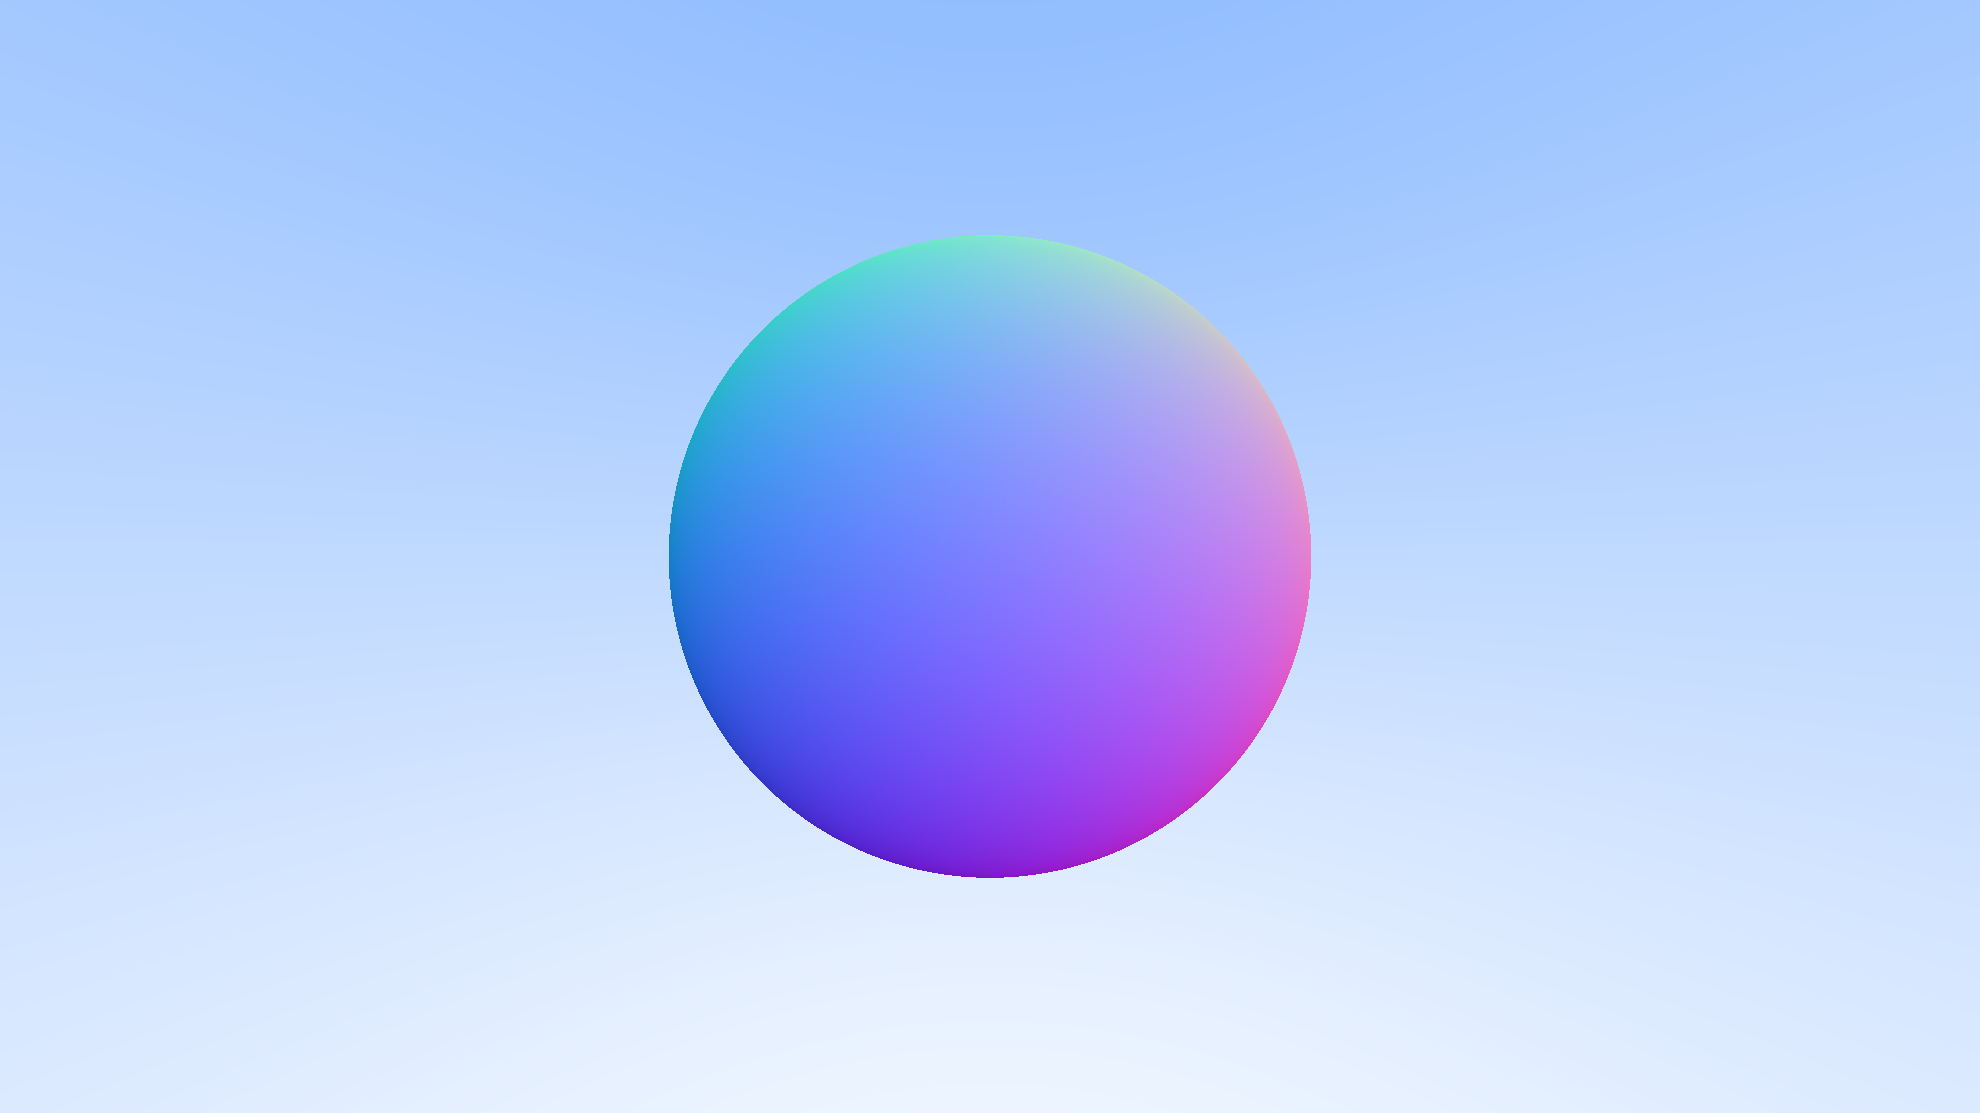

In [10]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")
from util.image_viewer import image_viewer
from util.scale_image import scale

a = image_viewer("output.ppm")
a

Below is the **story difference** between the two versions — not “code difference”, but what changed in the **math thinking, formulas, and purpose**.

---

# 🧠 Ray–Sphere Intersection: Old vs New Thinking

## 🎯 Big Idea (Same in both)

We are solving this:

> When does a ray hit a sphere?

Mathematically, this becomes a **quadratic equation in (t)**:

$$
a t^2 + b t + c = 0
$$

---

# 📊 Core Difference Table (Old vs New)
Here’s the corrected table with consistent columns, properly escaped pipes (none needed inside math), and fixed LaTeX for the malformed entries. I removed the empty trailing columns and made the “Meaning” column clearly align with each row.

| Concept              | 🧮 Old Formulation                                 | 🧠 New Formulation                          | Meaning (Story)                                    |
| -------------------- | -------------------------------------------------- | ------------------------------------------- | -------------------------------------------------- |
| **Direction term**   | $a = \vec{d} \cdot \vec{d}$                        | $a = \lvert \vec{d} \rvert^2$               | Same thing, rewritten as “length squared”          |
| **Center‑to‑ray vector** | $\text{oc} = C - O$                                | same                                        | Geometry unchanged                                 |
| **Linear term**      | $b = -2\,(\vec{d} \cdot \text{oc})$                | $h = \vec{d} \cdot \text{oc}$               | Hide the “‑2” inside a new variable                |
| **Constant term**    | $c = \lvert \text{oc} \rvert^2 - r^2$              | same                                        | Distance from center squared minus radius²         |
| **Discriminant**     | $b^2 - 4ac$                                        | $h^2 - ac$                                  | Simplified using substitution (factor 4 dropped)   |
| **Root formula**     | $t = \dfrac{-b \pm \sqrt{b^2 - 4ac}}{2a}$          | $t = \dfrac{h \pm \sqrt{h^2 - ac}}{a}$      | Cleaner quadratic solution                         |

---

**Note on the discriminant:**  
In the new formulation, $b = -2h$ so $b^2 - 4ac = 4(h^2 - ac)$. The root formula uses $\sqrt{h^2 - ac}$ because the factor of $4$ cancels with the $2a$ denominator — the table correctly reflects this simplified form.

---

# 🧾 Formula Transformation Story

## 🧮 Step 1: Start with standard quadratic

$$
t = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}
$$

---

## 🧠 Step 2: Notice structure of (b)

In ray tracing:

$$
b = -2h
$$

So we define:

$$
h = \vec{d} \cdot \text{oc}
$$

👉 This removes repeated dot products and simplifies algebra.

---

## 🧮 Step 3: Substitute into discriminant

### Old:

$$
b^2 - 4ac
$$

### Replace (b = -2h):

$$
(-2h)^2 - 4ac = 4h^2 - 4ac
$$

Factor out 4:

$$
4(h^2 - ac)
$$

---

## 🧮 Step 4: Substitute into root formula

$$
t = \frac{-(-2h) \pm \sqrt{4(h^2 - ac)}}{2a}
$$

Simplify:

* (-(-2h) = 2h)
* (\sqrt{4X} = 2\sqrt{X})

So:

$$
t = \frac{2h \pm 2\sqrt{h^2 - ac}}{2a}
$$

Cancel 2:

$$
t = \frac{h \pm \sqrt{h^2 - ac}}{a}
$$

---

# 🎯 Key Insight (The Real Story)

| Idea              | Meaning                                                        |
| ----------------- | -------------------------------------------------------------- |
| Old version       | Direct quadratic formula (general math tool)                   |
| New version       | Specialized ray-sphere algebra simplification                  |
| Why new is better | Removes repeated multiplications and reduces numerical clutter |
| Main trick        | Replace (b = -2h) to eliminate factors of 2                    |

---

# 🧠 Intuition (Very Important)

### Old code thinks like:

> “I will solve a general quadratic equation.”

### New code thinks like:

> “I know this quadratic always comes from dot products in ray geometry — so I simplify it ahead of time.”

---

# 🚀 Final Mental Model

### Old:

```
ray → quadratic → plug into formula → compute b, c, discriminant
```

### New:

```
ray → geometric dot products → simplified quadratic → fewer operations → same answer faster
```

---

If you want, I can next show:

* 🟢 Why we take only the **minus root**
* 🟢 Geometric meaning of (h = d·oc)
* 🟢 Visual intuition of the sphere intersection in 3D

Just tell 👍
